## **Langchain Agent *Intro*** 

In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [42]:
from pydantic import BaseModel

class WeatherOutput(BaseModel):
    temperature: float
    description: str

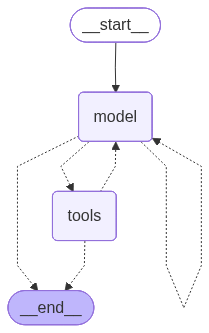

In [49]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")   

@tool
def get_weather(location: str) -> str:
    """A mock function to get weather information for a given location."""
    return f"The weather in {location} is sunny with a high of 25°C."

agent = create_agent(
    name = "WeatherAgent",
    model = llm,
    tools = [get_weather],
    system_prompt = "You are a helpful assistant. You can use the get_weather function to provide weather information for any location.",
    response_format = WeatherOutput,
)
agent 

In [44]:
response = agent.invoke({"message":[{"role": "user", "content": "What is the weather in New York?"}]})

In [47]:
response["messages"][-1].content

"Returning structured response: temperature=25.0 description='sunny'"

In [48]:
response["structured_response"]

WeatherOutput(temperature=25.0, description='sunny')